# 04 Logistic Regression

This notebook builds a multivariable logistic regression model to predict 
functional movement difficulty, and evaluates model performance using 
odds ratios, AUC, and ROC curve analysis.

Input: cleaned_data.csv (from notebook 02)

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np

# Load cleaned data
df = pd.read_csv('../data/cleaned_data.csv')

print("Sample size:", df.shape[0])
print(df[['sitting_hours', 'BMXBMI', 'RIDAGEYR', 'RIAGENDR', 'functional_limitation']].head())

Sample size: 1347
   sitting_hours  BMXBMI  RIDAGEYR  RIAGENDR  functional_limitation
0            5.0    30.7      61.0       1.0                      0
1            4.0    22.0      45.0       1.0                      0
2            2.0    35.9      60.0       2.0                      0
3            4.0    23.8      60.0       2.0                      0
4            2.0    22.4      64.0       1.0                      0


In [11]:
# Define predictors and outcome
# Removed: vigorous_activity (not significant in previous analysis)
# Added: FLI-based composite outcome replaces single PFQ061D
X = df[['sitting_hours', 'BMXBMI', 'RIDAGEYR', 'RIAGENDR', 'arthritis']]
y = df['functional_limitation']

# Add constant for intercept
X_const = sm.add_constant(X)

print("Predictors shape:", X_const.shape)
print("Outcome distribution:")
print(y.value_counts())

Predictors shape: (1347, 6)
Outcome distribution:
functional_limitation
1    877
0    470
Name: count, dtype: int64


In [12]:
# Fit logistic regression model
model = sm.Logit(y, X_const)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.567713
         Iterations 6
                             Logit Regression Results                            
Dep. Variable:     functional_limitation   No. Observations:                 1347
Model:                             Logit   Df Residuals:                     1341
Method:                              MLE   Df Model:                            5
Date:                   Fri, 05 Jun 2026   Pseudo R-squ.:                  0.1222
Time:                           14:22:14   Log-Likelihood:                -764.71
converged:                          True   LL-Null:                       -871.21
Covariance Type:               nonrobust   LLR p-value:                 4.687e-44
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.2084      0.423     -2.855      0.004      -2.038      -0.

In [13]:
# Model comparison: baseline vs. full model
# Demonstrates value of adding chronic condition data (arthritis)
X_baseline = df[['sitting_hours', 'BMXBMI', 'RIDAGEYR', 'RIAGENDR']]
X_baseline_const = sm.add_constant(X_baseline)
model_baseline = sm.Logit(y, X_baseline_const)
result_baseline = model_baseline.fit(disp=0)

y_prob_baseline = result_baseline.predict(X_baseline_const)
auc_baseline = roc_auc_score(y, y_prob_baseline)

print("=== Model Comparison ===")
print(f"Baseline model (without arthritis): AUC = {auc_baseline:.3f}")
print(f"Full model (with arthritis):        AUC = {auc:.3f}")
print(f"Improvement:                        +{auc - auc_baseline:.3f}")

=== Model Comparison ===
Baseline model (without arthritis): AUC = 0.621
Full model (with arthritis):        AUC = 0.731
Improvement:                        +0.110


In [14]:
# Extract odds ratios and confidence intervals from model
params = result.params
conf = result.conf_int()
conf.columns = ['CI_lower', 'CI_upper']

or_df = pd.DataFrame({
    'Variable': params.index,
    'Coefficient': params.values,
    'Odds_Ratio': np.exp(params.values),
    'CI_lower': np.exp(conf['CI_lower'].values),
    'CI_upper': np.exp(conf['CI_upper'].values),
    'p_value': result.pvalues.values
}).round(3)

# Remove intercept row
or_df = or_df[or_df['Variable'] != 'const']

print(or_df)

        Variable  Coefficient  Odds_Ratio  CI_lower  CI_upper  p_value
1  sitting_hours        0.054       1.055     1.016     1.095    0.005
2         BMXBMI        0.043       1.044     1.027     1.062    0.000
3       RIDAGEYR       -0.009       0.991     0.981     1.001    0.074
4       RIAGENDR        0.081       1.085     0.849     1.385    0.515
5      arthritis        1.586       4.884     3.716     6.419    0.000


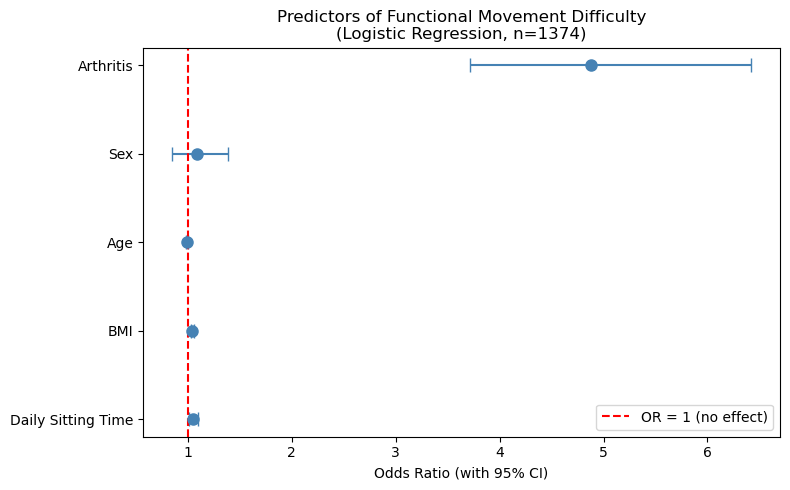

In [15]:
label_map = {
    'sitting_hours': 'Daily Sitting Time',
    'BMXBMI': 'BMI',
    'RIDAGEYR': 'Age',
    'RIAGENDR': 'Sex',
    'arthritis': 'Arthritis'
}
or_df['Label'] = or_df['Variable'].map(label_map)

plt.figure(figsize=(8, 5))
plt.errorbar(
    or_df['Odds_Ratio'], or_df['Label'],
    xerr=[or_df['Odds_Ratio'] - or_df['CI_lower'],
          or_df['CI_upper'] - or_df['Odds_Ratio']],
    fmt='o', color='steelblue', capsize=5, markersize=8
)
plt.axvline(x=1, color='red', linestyle='--', label='OR = 1 (no effect)')
plt.xlabel('Odds Ratio (with 95% CI)')
plt.title('Predictors of Functional Movement Difficulty\n(Logistic Regression, n=1374)')
plt.legend()
plt.tight_layout()
plt.savefig('../visualizations/05_odds_ratio_plot.png', dpi=150)
plt.show()

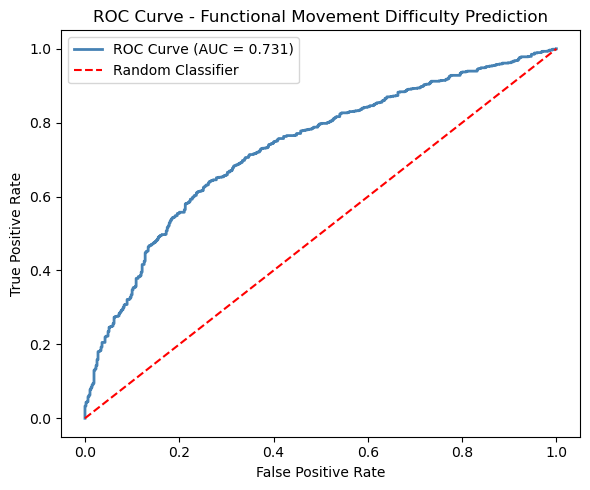

AUC: 0.731


In [16]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities from statsmodels
y_prob = result.predict(X_const)

# ROC curve
fpr, tpr, _ = roc_curve(y, y_prob)
auc = roc_auc_score(y, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Functional Movement Difficulty Prediction')
plt.legend()
plt.tight_layout()
plt.savefig('../visualizations/06_roc_curve.png', dpi=150)
plt.show()

print("AUC:", round(auc, 3))

In [17]:
# Sensitivity analysis: repeat with stricter outcome (FLI >= 2)
y_strict = df['functional_limitation_strict']
model_strict = sm.Logit(y_strict, X_const)
result_strict = model_strict.fit()

y_prob_strict = result_strict.predict(X_const)
auc_strict = roc_auc_score(y_strict, y_prob_strict)

print(f"Primary model AUC (FLI>=1): {auc:.3f}")
print(f"Strict model AUC (FLI>=2): {auc_strict:.3f}")
print("\nStrict model summary:")
print(result_strict.summary().tables[1])

Optimization terminated successfully.
         Current function value: 0.614039
         Iterations 5
Primary model AUC (FLI>=1): 0.731
Strict model AUC (FLI>=2): 0.720

Strict model summary:
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.6882      0.407     -4.147      0.000      -2.486      -0.890
sitting_hours     0.0483      0.018      2.712      0.007       0.013       0.083
BMXBMI            0.0429      0.008      5.466      0.000       0.028       0.058
RIDAGEYR         -0.0078      0.005     -1.581      0.114      -0.017       0.002
RIAGENDR         -0.1098      0.120     -0.916      0.360      -0.345       0.125
arthritis         1.4369      0.124     11.623      0.000       1.195       1.679


In [18]:
# Risk stratification framework
# Threshold based on tertiles of predicted probability
df['risk_score'] = result.predict(X_const)

low_thresh = df['risk_score'].quantile(0.33)
high_thresh = df['risk_score'].quantile(0.67)

df['risk_tier'] = pd.cut(df['risk_score'],
                          bins=[0, low_thresh, high_thresh, 1.0],
                          labels=['Low Risk', 'Moderate Risk', 'High Risk'])

print("Risk tier thresholds:")
print(f"  Low Risk: score < {low_thresh:.3f}")
print(f"  Moderate Risk: {low_thresh:.3f} - {high_thresh:.3f}")
print(f"  High Risk: score > {high_thresh:.3f}")

print("\nRisk tier distribution:")
print(df['risk_tier'].value_counts().sort_index())

print("\nFunctional limitation rate by risk tier:")
print(df.groupby('risk_tier', observed=True)['functional_limitation'].mean().round(3))

Risk tier thresholds:
  Low Risk: score < 0.514
  Moderate Risk: 0.514 - 0.797
  High Risk: score > 0.797

Risk tier distribution:
risk_tier
Low Risk         445
Moderate Risk    457
High Risk        445
Name: count, dtype: int64

Functional limitation rate by risk tier:
risk_tier
Low Risk         0.436
Moderate Risk    0.652
High Risk        0.865
Name: functional_limitation, dtype: float64


## Risk Stratification Framework

The model assigns each individual a predicted probability of functional 
limitation, stratified into three tiers using tertile thresholds:

| Risk Tier | Predicted Probability | Observed Limitation Rate |
|-----------|----------------------|--------------------------|
| Low Risk | < 0.514 | 43.6% |
| Moderate Risk | 0.514 – 0.797 | 65.2% |
| High Risk | > 0.797 | 86.5% |

Individuals in the High Risk tier may benefit from early functional 
assessment and rehabilitation referral. This framework demonstrates 
how routinely collected EHR data could support proactive clinical 
decision-making, a core application of Health Informatics.

In [19]:
# Print results summary with significance indicators
print("=== Logistic Regression Results (statsmodels) ===\n")
for _, row in or_df.iterrows():
    sig = "significant" if row['p_value'] < 0.05 else "not significant"
    print(f"{row['Label']:25s} OR={row['Odds_Ratio']:.3f} "
          f"95%CI [{row['CI_lower']:.3f}, {row['CI_upper']:.3f}] "
          f"p={row['p_value']:.3f} ({sig})")

=== Logistic Regression Results (statsmodels) ===

Daily Sitting Time        OR=1.055 95%CI [1.016, 1.095] p=0.005 (significant)
BMI                       OR=1.044 95%CI [1.027, 1.062] p=0.000 (significant)
Age                       OR=0.991 95%CI [0.981, 1.001] p=0.074 (not significant)
Sex                       OR=1.085 95%CI [0.849, 1.385] p=0.515 (not significant)
Arthritis                 OR=4.884 95%CI [3.716, 6.419] p=0.000 (significant)


## Clinical Implications

The addition of arthritis diagnosis to the predictive model substantially 
improved discriminative performance (AUC: 0.621 → 0.731), demonstrating 
that chronic condition data provides meaningful predictive value beyond 
demographic and lifestyle variables alone.

Arthritis showed the strongest independent association with functional 
limitation (OR=4.88, p<0.001), followed by BMI (OR=1.044, p<0.001) and 
daily sitting time (OR=1.055, p=0.005). These findings were consistent 
across both primary (FLI≥1) and strict (FLI≥2) outcome definitions 
(AUC=0.731 and 0.720 respectively), confirming the robustness of results.

The Functional Limitation Index, constructed from four mobility items 
with Cronbach's α=0.818, provides a more comprehensive assessment of 
functional status than single-item outcomes.

Despite improved performance, AUC=0.731 indicates that substantial 
predictive variance remains unexplained. Key clinical variables absent 
from population surveys — including muscle strength, joint range of motion, 
and pain severity — likely account for this gap. This highlights a 
fundamental limitation of current health data infrastructure and points 
to the need for standardized functional assessment data in EHR systems, 
which represents a core challenge for Health Informatics.